# Lab 3: Histological image classification leveraging Bag Of Features

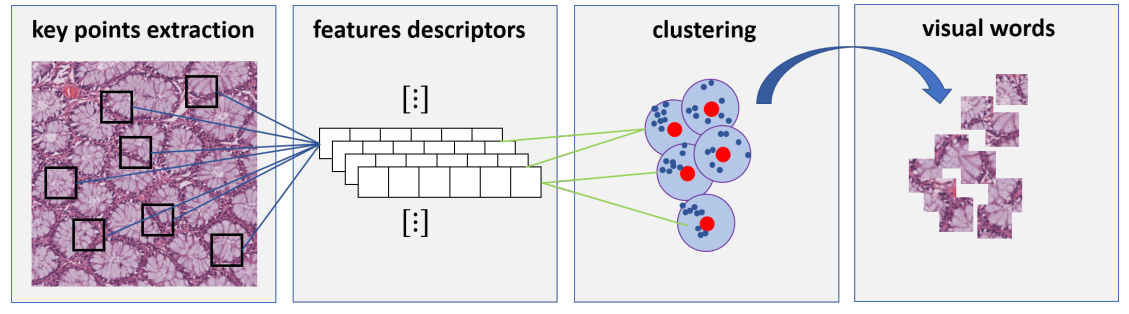

## Import and settings

In [33]:
import os
import cv2
import glob
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [34]:
# from google.colab import drive
# drive.mount('/content/drive')

In [35]:
# !cp -r /content/dataset-BIOSTEC2018/crc_images /content/drive/MyDrive/lab

In [36]:
#!git clone https://github.com/frpnz/dataset-BIOSTEC2018.git
# ROOTDIR_DATASET = "/content/drive/MyDrive/lab/crc_images"
ROOTDIR_DATASET = "/content/dataset-BIOSTEC2018/crc_images"

## Utils
The well-know function to plot a nice confusion matrix

In [37]:
def seaborn_cm(cm, ax, tick_labels, fontsize=14, title=None, sum_actual="over_columns",
               xrotation=0, yrotation=0):
    """
    Function to plot a confusion matrix
    """
    from matplotlib import cm as plt_cmap
    group_counts = ["{:0.0f}".format(value) for value in cm.flatten()]
    if sum_actual == "over_columns":
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif sum_actual == "over_rows":
        cm = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]
    else:
        print("sum_actual must be over_columns or over_rows")
        exit()
    cm = np.nan_to_num(cm)
    mean_acc = np.mean(np.diag(cm)[cm.sum(axis=1) != 0])
    std_acc = np.std(np.diag(cm))
    group_percentages = ["{:0.0f}".format(value*100) for value in cm.flatten()]
    cm_labels = [f"{c}\n{p}%" for c, p in zip(group_counts, group_percentages)]
    cm_labels = np.asarray(cm_labels).reshape(len(tick_labels), len(tick_labels))
    sns.heatmap(cm,
                ax=ax,
                annot=cm_labels,
                fmt='',
                cbar=False,
                cmap=plt_cmap.Greys,
                linewidths=1, linecolor='black',
                annot_kws={"fontsize": fontsize},
                xticklabels=tick_labels,
                yticklabels=tick_labels)
    ax.set_yticklabels(ax.get_yticklabels(), size=fontsize, rotation=yrotation)
    ax.set_xticklabels(ax.get_xticklabels(), size=fontsize, rotation=xrotation)
    if title:
        title = f"{title}\nMean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    else:
        title = f"Mean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    ax.set_title(title)
    if sum_actual == "over_columns":
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    else:
        ax.set_ylabel("Predicted")
        ax.set_xlabel("Actual")
    ax.axis("off")

Write a class to handle the dataset.
Such class must return a dict with

*   key = class
*   value = list of tuples (image, filepath)

Where image is a numpy array of shape (90, 90, 3). Hence, the images must be resized. See functions in [OpenCV-Python](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html), a library of Python bindings designed to solve computer vision problem.

In [38]:
class Dataset:
    def __init__(self, path):
        self.path = path

    def getFiles(self):
        """
        returns a dict with key = object_name and value = list of tuples (image, filepath)
        """
        image_dict = dict()
        for subdir in glob.glob(f"{self.path}/*/", recursive=False):
            word = os.path.basename(os.path.normpath(subdir))
            image_dict[word] = list()
            for image_file in glob.glob(f"{subdir}/*", recursive=False):
                image = cv2.imread(image_file, 1)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (90, 90))
                image_dict[word].append((image, image_file))
        return image_dict

In [39]:
path_train = os.path.join(ROOTDIR_DATASET, "train")
dataset = Dataset(path_train)
dataset_train = dataset.getFiles()

# Assignment #1: Plot some random images to ensure the images to be correctly loaded.
This should be their aspect.

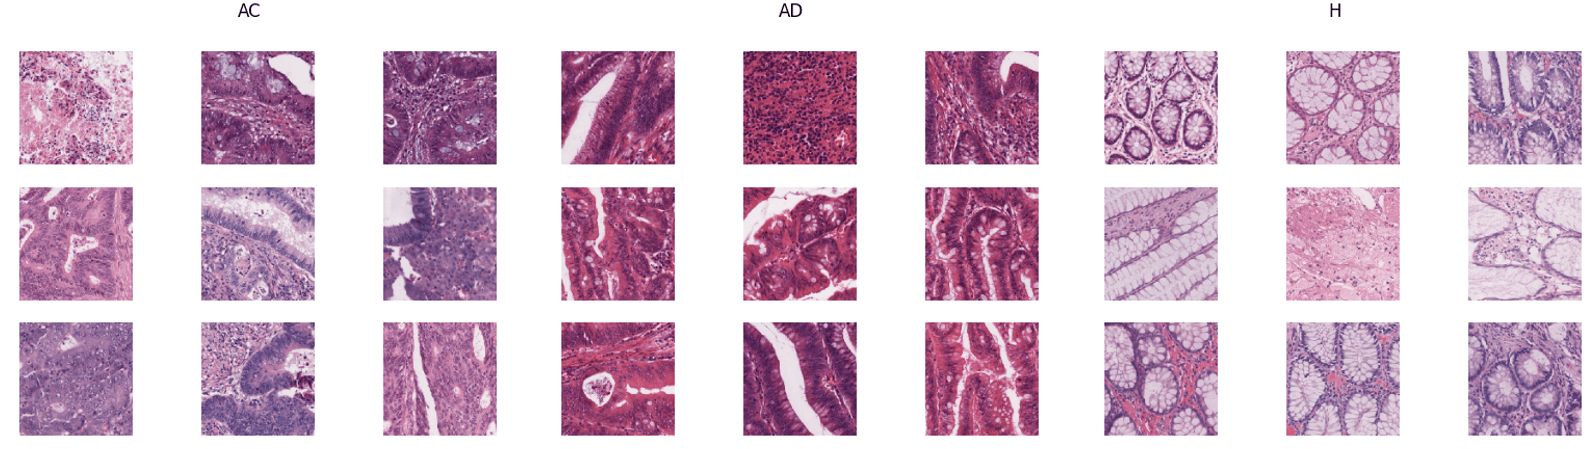

In [40]:
dataset_train['AC'][0]

(array([[[203, 145, 177],
         [190, 119, 159],
         [194, 134, 170],
         ...,
         [170, 106, 148],
         [161,  98, 143],
         [149,  93, 135]],
 
        [[184, 119, 161],
         [175, 111, 154],
         [184, 122, 163],
         ...,
         [198, 144, 178],
         [171, 115, 156],
         [163,  98, 145]],
 
        [[158, 102, 146],
         [168, 104, 150],
         [171, 111, 155],
         ...,
         [188, 128, 165],
         [147,  84, 136],
         [177, 118, 165]],
 
        ...,
 
        [[176, 111, 154],
         [171, 116, 157],
         [150,  93, 140],
         ...,
         [167,  94, 140],
         [179, 102, 139],
         [219, 175, 195]],
 
        [[163, 102, 149],
         [171, 113, 154],
         [168, 109, 150],
         ...,
         [154,  87, 132],
         [165,  96, 138],
         [162,  91, 136]],
 
        [[150, 101, 144],
         [148,  95, 143],
         [150,  92, 140],
         ...,
         [177, 102, 144],
  

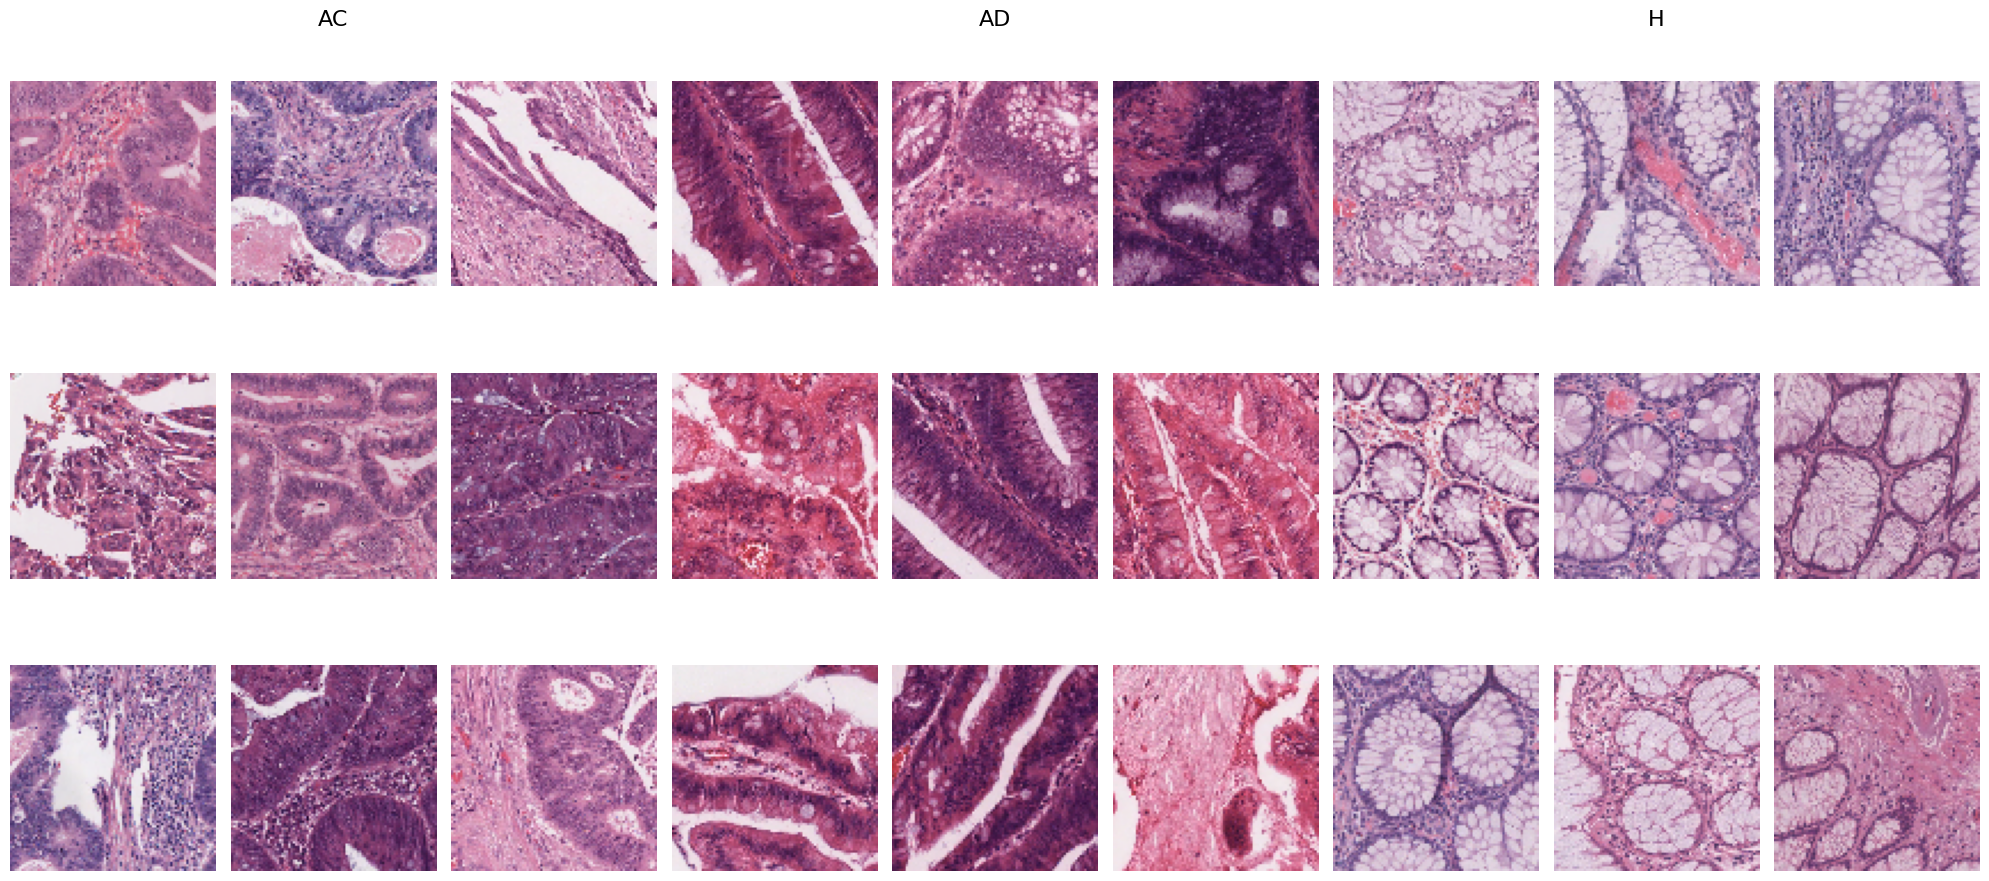

In [41]:
from numpy._core.multiarray import packbits
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

f, axes = plt.subplots(3,9, figsize=(20,10))

categories = ['AC', 'AD', 'H']
col_offsets = {'AC': 0, 'AD': 3, 'H': 6}

# for key in dataset_train:
#   print(dataset_train[key])

for category in categories:
    offset = col_offsets[category]
    img_idx = 0

    for row in range(3):
        for col in range(3):
            ax = axes[row, offset + col]
            try:
              img = dataset_train[category][img_idx][0]
              ax.imshow(img,)
              if row == 0 and col == 1:
                ax.set_title(category, fontsize=16, pad=40)
            except IndexError:
                pass

            ax.axis('off')
            img_idx += 1

plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.tight_layout()
plt.show()



# ax1.set_title('AC')
# ax1.imshow(dataset_train['AC'][0][0])

# ax2.set_title('AD')
# ax2.imshow(dataset_train['AD'][0][0])

# ax3.set_title('H')
# ax3.imshow(dataset_train['H'][0][0])



In [42]:
class ImageHelpers:
    def __init__(self):
        self.sift_object = cv2.SIFT_create()

    def gray(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        return gray

    def features(self, image):
        keypoints, descriptors = self.sift_object.detectAndCompute(image, None)
        return [keypoints, descriptors]

Extract SIFT descriptors for all the images. See an example [here](https://vovkos.github.io/doxyrest-showcase/opencv/sphinxdoc/page_tutorial_py_sift_intro.html)

Using SIFT, we detect and extract features inside each image. SIFT through OPENCV returns us a  `m x 128` dimension array, where `m` is the number of features extrapolated. Note that `m changes among different images`, depending on which features are detected. In some extreme cases (specifically when the image resolution is lower than 128x128) I experienced to get no detected features at all for some images.

In [43]:
# extract SIFT Features from each image
class Descriptors:
    def __init__(self, dataset):
        self.dataset = dataset
        self.im_helper = ImageHelpers()

    def GetDescriptors(self):
        labels = list()
        descriptor_list = list()
        name_dict = dict()
        label_count = 0
        for word, imlist in self.dataset.items():
            name_dict[label_count] = word
            for im, filepath in imlist:
                kp, des = self.im_helper.features(im)
                if des is None:
                    print(f"Cannot extract SIFT for {filepath}.")
                    continue
                descriptor_list.append(des)
                labels.append(label_count)
            label_count += 1
        return descriptor_list, labels, name_dict

# Assignment #2: # reshape list into np array of shape K samples x 128 features for sklearn



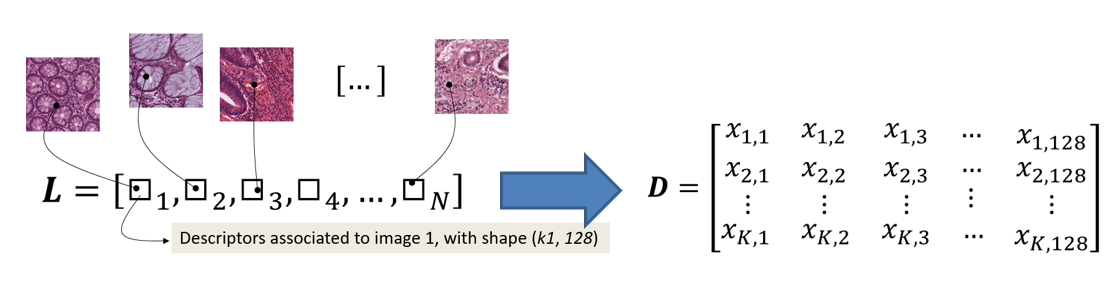

In [44]:
descriptor_extractor = Descriptors(dataset_train)
descriptor_list, labels, name_dict = descriptor_extractor.GetDescriptors()
descriptors_stacked = np.vstack(descriptor_list)
print(descriptors_stacked.shape)

(915095, 128)


# Assignment #3: Construction of the visual vocabulary by k-means clustering (see [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) implementation)
May require some time depending on the input resolution (~ 6/7 mins for 70x70 RGB images).

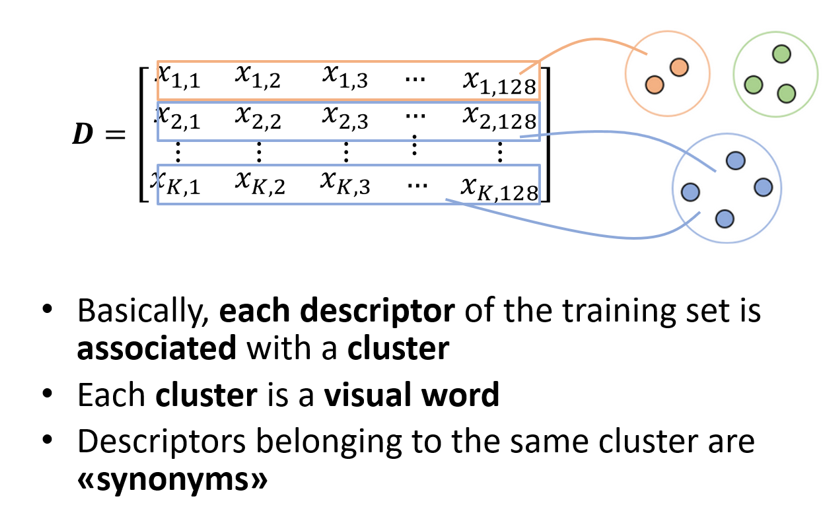

In [45]:
n_clusters = 60

kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
kmeans_pred_train = kmeans.fit_predict(descriptors_stacked)

visual_words = kmeans.cluster_centers_

print(f"Shape of visual vocabulary: {visual_words.shape}")

Shape of visual vocabulary: (60, 128)


# Assignment #4: Build the histogram of the visual words


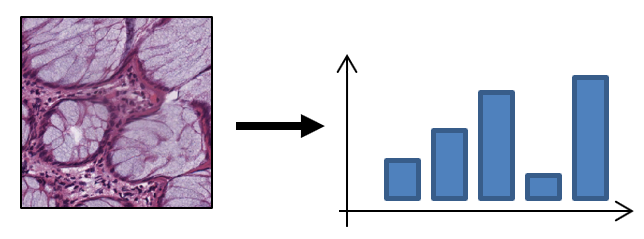

In [46]:
def MakeHistogram(descriptors_list, n_clusters, kmeans_pred):
    histogram_list = []

    current_idx = 0

    for des in descriptors_list:
        if des is None:
            continue
        num_descriptors = des.shape[0]

        image_cluster_labels = kmeans_pred[current_idx : current_idx + num_descriptors]

        current_idx += num_descriptors

        hist, _ = np.histogram(image_cluster_labels, bins=range(n_clusters + 1))
        histogram_list.append(hist)

    return np.array(histogram_list)



## Assignment #4.1: Scale the histogram of the visual words

In [47]:
from sklearn.preprocessing import StandardScaler

histogram_train = MakeHistogram(descriptor_list, n_clusters, kmeans_pred_train)
scaler = StandardScaler()

histogram_train_scaled = scaler.fit_transform(histogram_train.astype(float))
print(histogram_train_scaled.shape)

(9000, 60)


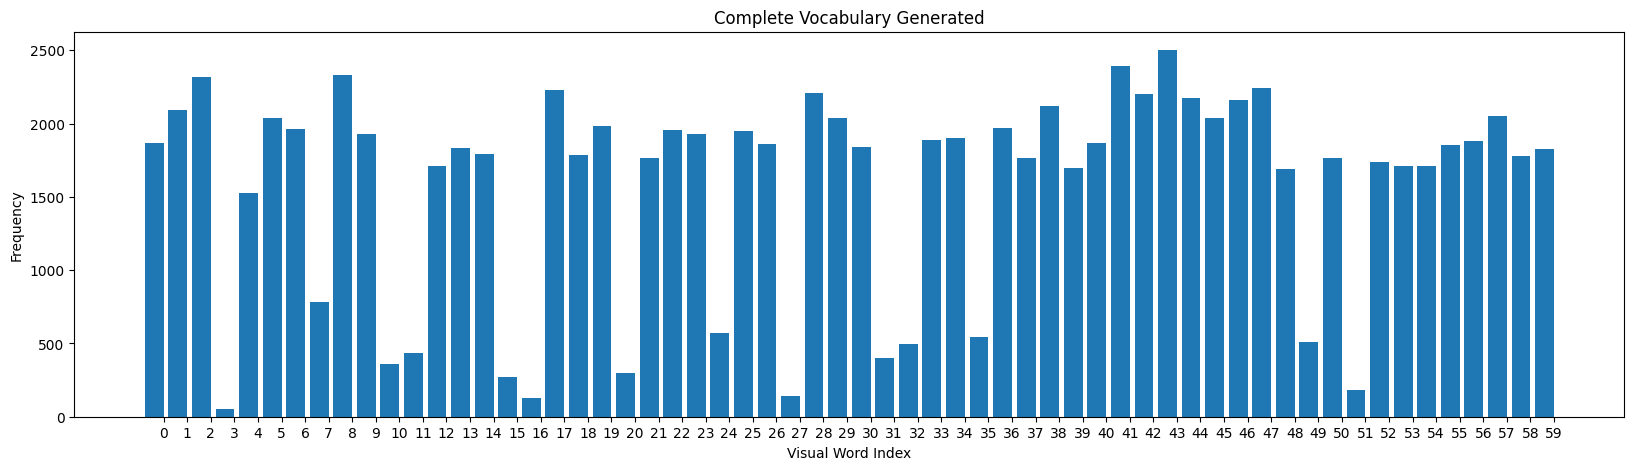

In [48]:
x_scalar = np.arange(n_clusters)
y_scalar = np.array([abs(np.sum(histogram_train_scaled[:,h], dtype=np.int32)) for h in range(n_clusters)])
plt.figure(figsize=(20, 5))
plt.bar(x_scalar, y_scalar)
plt.xlabel("Visual Word Index")
plt.ylabel("Frequency")
plt.title("Complete Vocabulary Generated")
plt.xticks(x_scalar + 0.4, x_scalar)
plt.show()

# Assignment #5: Train and then test an SVM on the histogram of the visual words

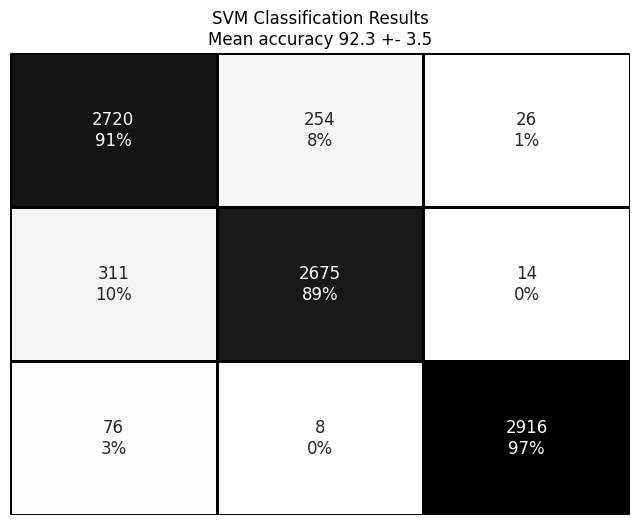

              precision    recall  f1-score   support

          AC       0.88      0.91      0.89      3000
          AD       0.91      0.89      0.90      3000
           H       0.99      0.97      0.98      3000

    accuracy                           0.92      9000
   macro avg       0.92      0.92      0.92      9000
weighted avg       0.92      0.92      0.92      9000



In [49]:
from sklearn.metrics import confusion_matrix, classification_report
# Initialize the SVM classifier
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)

# Train the model
svm_model.fit(histogram_train_scaled, labels)

# Predict on the training set
train_predictions = svm_model.predict(histogram_train_scaled)

# Generate the Confusion Matrix
tick_labels = [name_dict[i] for i in range(len(name_dict))]
cm = confusion_matrix(labels, train_predictions)

# Visualize - seaborn_cm
fig, ax = plt.subplots(figsize=(8, 6))
seaborn_cm(
    cm,
    ax,
    tick_labels,
    fontsize=12,
    title="SVM Classification Results",
    sum_actual="over_columns"
)
plt.show()

# Detailed Classification Report
print(classification_report(labels, train_predictions, target_names=tick_labels))

## Test the model

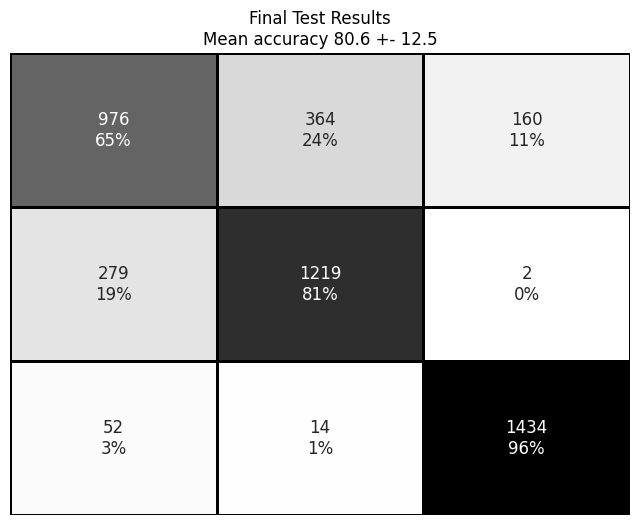

Test Classification Report:
              precision    recall  f1-score   support

          AC       0.75      0.65      0.70      1500
          AD       0.76      0.81      0.79      1500
           H       0.90      0.96      0.93      1500

    accuracy                           0.81      4500
   macro avg       0.80      0.81      0.80      4500
weighted avg       0.80      0.81      0.80      4500



In [50]:
# Load the test dataset
path_test = os.path.join(ROOTDIR_DATASET, "test")
dataset_test_obj = Dataset(path_test)
dataset_test = dataset_test_obj.getFiles()

# Extract SIFT descriptors for the test images
test_descriptors_handler = Descriptors(dataset_test)
test_descriptor_list, test_labels, _ = test_descriptors_handler.GetDescriptors()
test_descriptors_stacked = np.vstack(test_descriptor_list)
kmeans_pred_test = kmeans.predict(test_descriptors_stacked)

# Build histograms for the test data
histogram_test = MakeHistogram(test_descriptor_list, n_clusters, kmeans_pred_test)

# Scale the test histograms
histogram_test_scaled = scaler.transform(histogram_test.astype(float))

# Predict and Evaluate
test_predictions = svm_model.predict(histogram_test_scaled)

# Visualize the Test Results
cm_test = confusion_matrix(test_labels, test_predictions)
fig, ax = plt.subplots(figsize=(8, 6))

# Using the utility function from the sources
seaborn_cm(
    cm_test,
    ax,
    tick_labels,
    fontsize=12,
    title="Final Test Results",
    sum_actual="over_columns"
)
plt.show()

# Print final metrics
print("Test Classification Report:")
print(classification_report(test_labels, test_predictions, target_names=tick_labels))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters found: {'C': np.float64(3.4890188454913864), 'gamma': 'scale', 'kernel': 'rbf'}


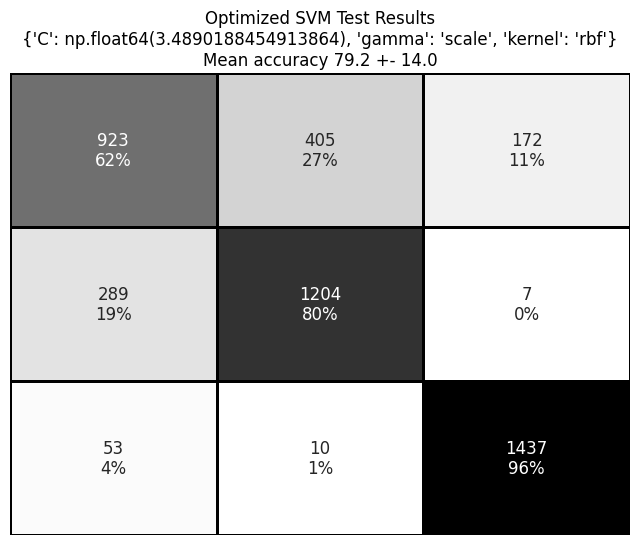

Optimized Test Classification Report:
              precision    recall  f1-score   support

          AC       0.73      0.62      0.67      1500
          AD       0.74      0.80      0.77      1500
           H       0.89      0.96      0.92      1500

    accuracy                           0.79      4500
   macro avg       0.79      0.79      0.79      4500
weighted avg       0.79      0.79      0.79      4500



In [51]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_distributions = {
    'C': stats.loguniform(0.1, 100),
    'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

base_svm = SVC(probability=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=base_svm,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2  )


random_search.fit(histogram_train_scaled, labels)


print("Best Parameters found:", random_search.best_params_)

best_svm_model = random_search.best_estimator_

best_test_predictions = best_svm_model.predict(histogram_test_scaled)


cm_best_test = confusion_matrix(test_labels, best_test_predictions)
fig, ax = plt.subplots(figsize=(8, 6))

seaborn_cm(
    cm_best_test,
    ax,
    tick_labels,
    fontsize=12,
    title=f"Optimized SVM Test Results\n{random_search.best_params_}",
    sum_actual="over_columns"
)
plt.show()

print("Optimized Test Classification Report:")
print(classification_report(test_labels, best_test_predictions, target_names=tick_labels))